In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import spacy
from nltk.corpus import stopwords
from bertopic import BERTopic
from sklearn.linear_model              import LogisticRegression
from sklearn.model_selection           import cross_val_score, train_test_split
from sklearn.metrics                   import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text   import CountVectorizer
from hdbscan import HDBSCAN

/opt/anaconda3/envs/text-analytics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data preparation

In [3]:
df = pd.read_csv('data/reddit_posts_further_reduced.csv')

In [4]:
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')

In [5]:
df = df.rename(columns={"Title": "title", "Text": "selftext"})

In [6]:
def minimal_clean(text: str) -> str:
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"https?://\S+", "", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# clean the df
df["title_clean"]    = df["title"].apply(minimal_clean)
df["selftext_clean"] = df["selftext"].apply(minimal_clean)

## Topic Modeling

In [7]:
# combine into docs for bertopic
docs = (df["title_clean"] + " " + df["selftext_clean"].fillna("")).tolist()
y = df["Political Lean"].map({"Liberal": 0, "Conservative": 1})

In [18]:
# Fit BERTopic with full probability matrix
topic_model = BERTopic(embedding_model="all-mpnet-base-v2", calculate_probabilities=True, verbose=True, top_n_words =30)
topics, probs = topic_model.fit_transform(docs)

2025-06-05 11:07:08,793 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 313/313 [01:03<00:00,  4.93it/s]
2025-06-05 11:08:14,746 - BERTopic - Embedding - Completed ✓
2025-06-05 11:08:14,747 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-05 11:08:17,806 - BERTopic - Dimensionality - Completed ✓
2025-06-05 11:08:17,807 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-05 11:08:23,149 - BERTopic - Cluster - Completed ✓
2025-06-05 11:08:23,152 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-06-05 11:08:23,380 - BERTopic - Representation - Completed ✓


5-fold CV AUC: 0.708 ± 0.040
5-fold CV Balanced Accuracy: 0.626 ± 0.017
              precision    recall  f1-score   support

     Liberal       0.79      0.78      0.78      1285
Conservative       0.61      0.62      0.62       715

    accuracy                           0.72      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.72      0.72      0.72      2000



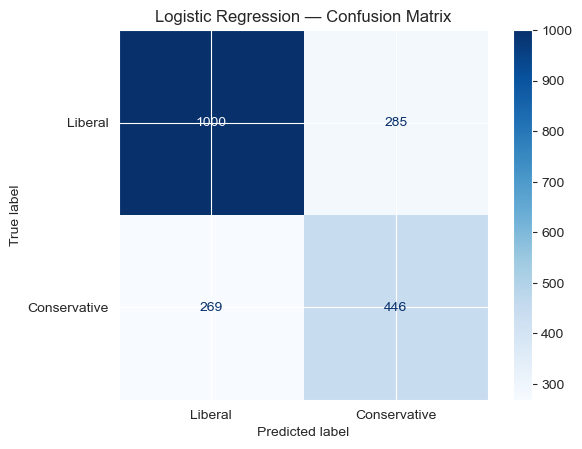

In [13]:
# Evaluate with 5-fold CV AUC
X = np.array(probs)                     # shape: (n_docs, n_topics)
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
auc_scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")
print(f"5-fold CV AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
bal_scores = cross_val_score(clf, X, y, cv=5, scoring="balanced_accuracy")
print(f"5-fold CV Balanced Accuracy: {bal_scores.mean():.3f} ± {bal_scores.std():.3f}")# better than accuracy metric because our classes are imbalanced

# Train/test split for confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Liberal","Conservative"]))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Liberal","Conservative"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [20]:
'''
# 4. Immediately merge down to 30 topics for interpretability
topic_model.reduce_topics(docs, nr_topics=30)
# 5. Re‐transform to get the probabilities over those 30 reduced topics
new_topics, new_probs = topic_model.transform(docs)
'''

2025-06-05 11:13:52,280 - BERTopic - Topic reduction - Reducing number of topics
2025-06-05 11:13:52,486 - BERTopic - Topic reduction - Reduced number of topics from 159 to 30
Batches: 100%|██████████| 313/313 [01:05<00:00,  4.81it/s]
2025-06-05 11:14:57,840 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-06-05 11:14:57,889 - BERTopic - Dimensionality - Completed ✓
2025-06-05 11:14:57,890 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-06-05 11:14:58,056 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-06-05 11:15:03,480 - BERTopic - Probabilities - Completed ✓
2025-06-05 11:15:03,480 - BERTopic - Cluster - Completed ✓


In [60]:
topic_model = BERTopic.load('data/bertopic_model')
new_topics, new_probs = topic_model.transform(docs)
topic_model.get_topic_info()

Batches: 100%|██████████| 313/313 [01:04<00:00,  4.85it/s]
2025-06-05 14:11:10,701 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-06-05 14:11:10,753 - BERTopic - Dimensionality - Completed ✓
2025-06-05 14:11:10,753 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-06-05 14:11:10,942 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-06-05 14:11:16,352 - BERTopic - Probabilities - Completed ✓
2025-06-05 14:11:16,352 - BERTopic - Cluster - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3917,-1_the_of_and_to,"[the, of, and, to, in, for, that, is, it, on, ...",[austrias revolutionary for social welfare - f...
1,0,853,0_the_of_and_to,"[the, of, and, to, is, that, in, you, it, capi...",[explaining the marxist methodology (wall of t...
2,1,658,1_biden_trump_to_for,"[biden, trump, to, for, joe, court, on, the, s...","[what has biden done , is this war going to be..."
3,2,604,2_ukraine_russia_russian_china,"[ukraine, russia, russian, china, the, to, and...",[the kremlin just sold out a generation i'm ru...
4,3,389,3_to_voting_the_in,"[to, voting, the, in, republicans, and, are, o...",[is it too late to save american democracy? i'...
5,4,327,4_whatever_you_weekly_unrelated,"[whatever, you, weekly, unrelated, please, ent...",[weekly discussion thread [55] feel free to di...
6,5,312,5_the_to_of_and,"[the, to, of, and, is, that, libertarian, peop...","[blowing the communist's ""nazis and fascist we..."
7,6,279,6_trudeau_police_canada_the,"[trudeau, police, canada, the, convoy, to, and...",[as a canadian this is the first time i've got...
8,7,259,7_trump_durham_probe_donald,"[trump, durham, probe, donald, committee, inve...",[new york prosecutors leading trump probe resi...
9,8,246,8_covid_health_the_insurance,"[covid, health, the, insurance, to, of, health...",[how to pay less for medicines: what can be le...


In [61]:
# load stop-words
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# Find top-skew topics per class
probs_df = pd.DataFrame(new_probs, columns=range(new_probs.shape[1]))
probs_df["class"] = y.values
mean_by_class = probs_df.groupby("class").mean()
diff = mean_by_class.loc[1] - mean_by_class.loc[0]

top_cons = diff.nlargest(8).index.tolist()
top_lib  = diff.nsmallest(8).index.tolist()

print("Top Conservative topics:", top_cons)
print("Top Liberal topics:     ", top_lib)

# 3) Print each topic’s top words, filtering out stop-words
for tid in top_cons:
    print(f"\n=== Topic {tid} (Conservative) ===")
    raw_keywords = topic_model.get_topic(tid)  # returns default list of top 20 (word, score)
    filtered     = [(w, s) for (w, s) in raw_keywords if w not in stop_words]
    for w, score in filtered[:10]:  # show top 10 non-stop-words
        print(f"  {w:15} {score:.4f}")

for tid in top_lib:
    print(f"\n=== Topic {tid} (Liberal) ===")
    raw_keywords = topic_model.get_topic(tid)
    filtered     = [(w, s) for (w, s) in raw_keywords if w not in stop_words]
    for w, score in filtered[:10]:
        print(f"  {w:15} {score:.4f}")

Top Conservative topics: [2, 17, 1, 6, 0, 13, 9, 18]
Top Liberal topics:      [10, 3, 11, 14, 15, 12, 21, 24]

=== Topic 2 (Conservative) ===
  ukraine         0.0535
  russia          0.0388
  russian         0.0274
  china           0.0250
  nato            0.0201
  putin           0.0180
  war             0.0165
  us              0.0154
  invasion        0.0141
  ukrainian       0.0125

=== Topic 17 (Conservative) ===
  desantis        0.3396
  florida         0.1462
  ron             0.1307
  gov             0.0879
  poll            0.0471
  cpac            0.0432
  orlando         0.0404
  trump           0.0344
  governor        0.0333
  gofundme        0.0307

=== Topic 1 (Conservative) ===
  biden           0.0880
  trump           0.0273
  joe             0.0200
  court           0.0181
  supreme         0.0165
  president       0.0141
  putin           0.0139
  ukraine         0.0137
  russia          0.0129
  manchin         0.0127

=== Topic 6 (Conservative) ===
  trudeau  

In [45]:
'''
# 3) Save the entire model to a file
model_path = "data/bertopic_model"
topic_model.save(model_path)
'''

'\n# 3) Save the entire model to a file\nmodel_path = "data/bertopic_model"\ntopic_model.save(model_path)\n'

In [46]:
raw_keywords = topic_model.get_topic(3)
raw_keywords

[('to', np.float64(0.025224930767462916)),
 ('voting', np.float64(0.02408463475331503)),
 ('the', np.float64(0.02142574498649884)),
 ('in', np.float64(0.019441213157457976)),
 ('republicans', np.float64(0.01806834213599684)),
 ('and', np.float64(0.017211921093241683)),
 ('are', np.float64(0.016834282996231516)),
 ('of', np.float64(0.016607592230901188)),
 ('vote', np.float64(0.016476810145220767)),
 ('we', np.float64(0.01631833576454157)),
 ('is', np.float64(0.015996510153368785)),
 ('this', np.float64(0.01592729164780843)),
 ('election', np.float64(0.015859807591249626)),
 ('for', np.float64(0.014731215724854176)),
 ('democrats', np.float64(0.014420111996216515)),
 ('that', np.float64(0.014143565444520381)),
 ('can', np.float64(0.013999036075486982)),
 ('party', np.float64(0.013719708266704435)),
 ('would', np.float64(0.01357636975513621)),
 ('texas', np.float64(0.013464538520116384)),
 ('voters', np.float64(0.013413859569867459)),
 ('have', np.float64(0.013305810440914268)),
 ('it', 

In [62]:
# per‐class mean probabilities
probs_df_2    = pd.DataFrame(new_probs, columns=range(new_probs.shape[1]))
probs_df_2["class"] = y.values   # 0=Liberal, 1=Conservative
mean_by_class = probs_df_2.groupby("class").mean()

# 2) For each topic t, record:
#       a) mean_L = mean_by_class.loc[0, t]
#       b) mean_C = mean_by_class.loc[1, t]
#       c) abs_diff = |mean_C − mean_L|
#       d) overall_mean = (mean_C + mean_L) / 2
diff = (mean_by_class.loc[1] - mean_by_class.loc[0]).abs()
overall_mean = (mean_by_class.loc[1] + mean_by_class.loc[0]) / 2

# Assemble into a DataFrame to sort/filter
common_df = pd.DataFrame({
    "mean_L":       mean_by_class.loc[0],
    "mean_C":       mean_by_class.loc[1],
    "abs_diff":     diff,
    "overall_mean": overall_mean
})

# Find topics with the smallest absolute difference (i.e. most “common” in both discourses)
common_df = common_df.sort_values(["abs_diff", "overall_mean"], ascending=[True, False])

# only pick topics that both sides discuss at a non‐trivial rate e.g. overall_mean > 0.03 (tune this threshold as you like)
common_df = common_df[common_df["overall_mean"] > 0.03]

# Pick the top k “common” topics
top_common = common_df.index.tolist()[:5]   # for example, the first 5

print("Top “common” topics (same prominence in both classes):", top_common)
print(common_df.loc[top_common])

# Display their keywords (filter out stop‐words if desired)
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

for tid in top_common:
    raw_keywords = topic_model.get_topic(tid)
    filtered     = [(w, s) for (w, s) in raw_keywords if w not in stop_words]
    print(f"\n=== Topic {tid} (common) ===")
    for w, score in filtered[:10]:
        print(f"  {w:15} {score:.4f}")


Top “common” topics (same prominence in both classes): [7, 5, 0, 11, 1]
      mean_L    mean_C  abs_diff  overall_mean
7   0.033555  0.034392  0.000837      0.033973
5   0.029344  0.034239  0.004895      0.031792
0   0.080823  0.094880  0.014057      0.087852
11  0.039954  0.020493  0.019461      0.030224
1   0.053974  0.074255  0.020281      0.064115

=== Topic 7 (common) ===
  trump           0.1576
  durham          0.0574
  probe           0.0393
  donald          0.0365
  committee       0.0347
  investigation   0.0345
  prosecutors     0.0330
  manhattan       0.0305
  cpac            0.0295
  clinton         0.0267

=== Topic 5 (common) ===
  libertarian     0.0192
  people          0.0185
  right           0.0151
  race            0.0146
  libertarians    0.0116

=== Topic 0 (common) ===
  capitalism      0.0148
  social          0.0124
  socialism       0.0101
  people          0.0095

=== Topic 11 (common) ===
  workers         0.0371
  strike          0.0213
  worker        

In [63]:
# Raw n-gram vocabulary comparison
vectorizer = CountVectorizer(stop_words="english", ngram_range=(1,2), max_features=5000)
X_cv = vectorizer.fit_transform(docs)
vocab = vectorizer.get_feature_names_out()

vocab_df = pd.DataFrame(X_cv.toarray(), columns=vocab)
vocab_df["class"] = y.values
counts = vocab_df.groupby("class").sum()

print("\nTop 20 terms (Liberal):")
print(counts.loc[0].nlargest(20), "\n")
print("Top 20 terms (Conservative):")
print(counts.loc[1].nlargest(20))


Top 20 terms (Liberal):
people        1169
like           890
social         711
just           685
workers        678
party          637
trump          589
new            579
state          528
think          513
time           489
right          468
don            447
government     447
socialist      444
democracy      438
democratic     437
women          430
world          420
war            403
Name: 0, dtype: int64 

Top 20 terms (Conservative):
people        726
trump         436
capitalism    426
government    390
like          382
just          377
ukraine       374
biden         367
russia        336
think         293
state         282
don           270
free          223
money         223
right         219
time          212
new           205
x200b         205
make          202
work          197
Name: 1, dtype: int64


In [64]:
import numpy as np
import pandas as pd

n = 5  # number of top posts per class to inspect

# 1) (Re)compute normalized score within each subreddit
df["norm_score"] = (
    df.groupby("Subreddit")["Score"]
    .transform(lambda x: x / x.max())
)

# 2) Build a DataFrame of topic probabilities + class + norm_score
probs_df_3 = pd.DataFrame(new_probs, columns=[f"topic_{i}" for i in range(new_probs.shape[1])])
probs_df_3["class"]     = y.values
probs_df_3["norm_score"] = df["norm_score"].values

# 3) For each class, take the top n rows by norm_score
top_posts = {0: [], 1: []}
for cl in [0, 1]:
    subset = probs_df_3[probs_df_3["class"] == cl]
    # sort descending by norm_score, then take the first n indices
    top_indices = subset.sort_values("norm_score", ascending=False).head(n).index.tolist()

    for idx in top_indices:
        row = subset.loc[idx]
        topic_probs = row[row.index.str.startswith("topic_")].values
        best_topic  = int(np.argmax(topic_probs))
        general_top = top_lib if cl == 0 else top_cons
        matches     = best_topic in general_top

        top_posts[cl].append({
            "index": idx,
            "norm_score": float(row["norm_score"]),
            "best_topic": best_topic,
            "matches_general_top": matches
        })

# 4) Print results for each of the top n posts per class
for cl, posts in top_posts.items():
    label      = "Liberal" if cl == 0 else "Conservative"
    general_top = top_lib if cl == 0 else top_cons

    print(f"=== Top {n} posts for {label} ===")
    print(f"General top topics for {label}: {general_top}\n")
    for i, data in enumerate(posts, 1):
        print(f"{i}. Row index:          {data['index']}")
        print(f"   Normalized score:   {data['norm_score']:.3f}")
        print(f"   Top‐probability topic: {data['best_topic']}")
        print(f"   Matches general top?  {'Yes' if data['matches_general_top'] else 'No'}\n")
    print("------------------------------------------------\n")


=== Top 5 posts for Liberal ===
General top topics for Liberal: [10, 3, 11, 14, 15, 12, 21, 24]

1. Row index:          3196
   Normalized score:   1.000
   Top‐probability topic: 0
   Matches general top?  No

2. Row index:          4752
   Normalized score:   1.000
   Top‐probability topic: 7
   Matches general top?  No

3. Row index:          5968
   Normalized score:   1.000
   Top‐probability topic: 10
   Matches general top?  Yes

4. Row index:          1049
   Normalized score:   1.000
   Top‐probability topic: 0
   Matches general top?  No

5. Row index:          5734
   Normalized score:   1.000
   Top‐probability topic: 7
   Matches general top?  No

------------------------------------------------

=== Top 5 posts for Conservative ===
General top topics for Conservative: [2, 17, 1, 6, 0, 13, 9, 18]

1. Row index:          7793
   Normalized score:   1.000
   Top‐probability topic: 4
   Matches general top?  No

2. Row index:          9013
   Normalized score:   1.000
   Top‐

In [70]:
topic_info = topic_model.get_topic_info()
all_tids   = topic_info[topic_info.Topic != -1]["Topic"].tolist() # remove the outlier topic

# For each topic ID, fetch its (word, score) list and filter stop-words
for tid in all_tids:
    raw_keywords = topic_model.get_topic(tid)
    filtered     = [(w, s) for (w, s) in raw_keywords if w not in stop_words]

    print(f"\n=== Topic {tid} ===")
    for w, score in filtered[:10]:                 # show top 10 non–stop-words
        print(f"  {w:15} {score:.4f}")


=== Topic 0 ===
  capitalism      0.0148
  social          0.0124
  socialism       0.0101
  people          0.0095

=== Topic 1 ===
  biden           0.0880
  trump           0.0273
  joe             0.0200
  court           0.0181
  supreme         0.0165
  president       0.0141
  putin           0.0139
  ukraine         0.0137
  russia          0.0129
  manchin         0.0127

=== Topic 2 ===
  ukraine         0.0535
  russia          0.0388
  russian         0.0274
  china           0.0250
  nato            0.0201
  putin           0.0180
  war             0.0165
  us              0.0154
  invasion        0.0141
  ukrainian       0.0125

=== Topic 3 ===
  voting          0.0241
  republicans     0.0181
  vote            0.0165
  election        0.0159
  democrats       0.0144
  party           0.0137
  would           0.0136
  texas           0.0135
  voters          0.0134
  arizona         0.0128

=== Topic 4 ===
  whatever        0.0817
  weekly          0.0531
  unrelated    